### <span style="color:lightgreen"> Case Study: Predicting Energy Consumption </span>

Train Data Shape: (576, 7)
Test Data Shape: (145, 7)
X_train shape: (552, 24, 7)
y_train shape: (552,)
Epoch 1/20


/var/folders/rg/b21vyw1s0v727y0fc2phllm00000gn/T/ipykernel_36839/3247476660.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2022 - val_loss: 0.0875
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0886 - val_loss: 0.0879
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0781 - val_loss: 0.0919
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0735 - val_loss: 0.0980
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0750 - val_loss: 0.0997
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0724 - val_loss: 0.1393
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0743 - val_loss: 0.1097
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0717 - val_loss: 0.1177
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0617 - val_loss: 0.1114
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0602 - val_loss: 0.1022
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0643 - val_loss: 0.1017
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0575 - val_loss: 0.1006

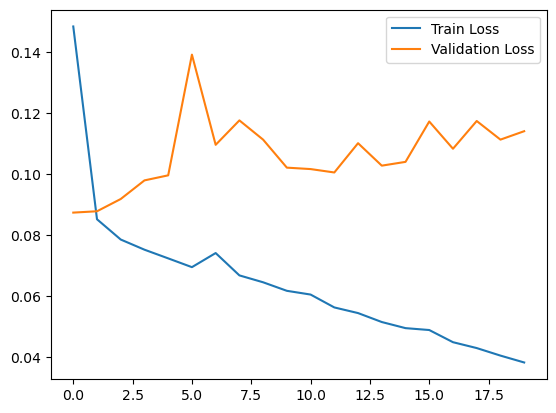

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x315449da0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


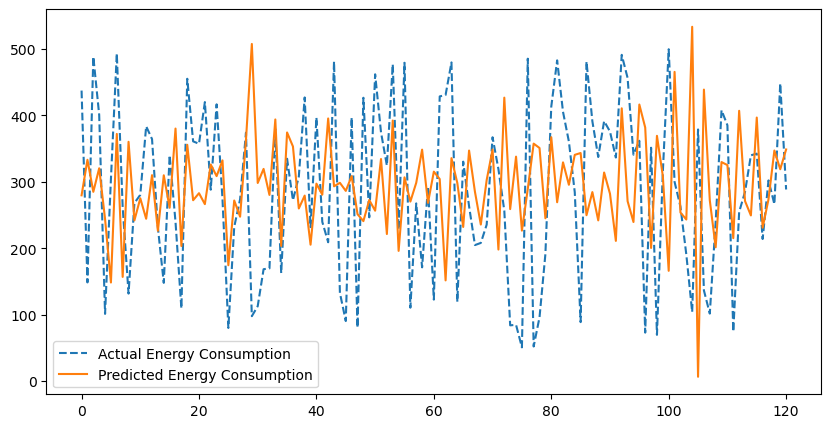

In [9]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt
import pickle

#Step 1: Load and Explore the Data
# Load dataset
data = pd.read_csv("energy_consumption.csv", parse_dates=['date_time'], index_col='date_time')

# Display first few rows
#print(data.head())

# Step 2: Handle Missing Values
data.fillna(method='ffill', inplace=True)

# Step 3: Feature Engineering
data['hour'] = data.index.hour
data['day'] = data.index.day
data['month'] = data.index.month

# step4: Select relevant columns
features = ['energy_usage', 'temperature', 'humidity', 'wind_speed', 'hour', 'day', 'month']
data = data[features]

# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Split into train and test sets
train_size = int(len(data_scaled) * 0.8)
train, test = data_scaled[:train_size], data_scaled[train_size:]

print("Train Data Shape:", train.shape)
print("Test Data Shape:", test.shape)

# Function to create sequences for RNN
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # Predict energy consumption
    return np.array(X), np.array(y)

seq_length = 24  # Use past 24 hours
X_train, y_train = create_sequences(train, seq_length)
X_test, y_test = create_sequences(test, seq_length)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Build and Train the RNN Model
# Build the RNN Model
model = Sequential([
    SimpleRNN(50, activation='relu', return_sequences=True, input_shape=(seq_length, X_train.shape[2])),
    SimpleRNN(50, activation='relu'),
    Dense(1)  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the Model

# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

# Predict on test set
y_pred = model.predict(X_test)

# Rescale predictions back to original scale
y_pred_rescaled = scaler.inverse_transform(np.c_[y_pred, np.zeros((len(y_pred), X_test.shape[2]-1))])[:,0]
y_test_rescaled = scaler.inverse_transform(np.c_[y_test, np.zeros((len(y_test), X_test.shape[2]-1))])[:,0]

# Plot Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled, label="Actual Energy Consumption", linestyle="dashed")
plt.plot(y_pred_rescaled, label="Predicted Energy Consumption")
plt.legend()
plt.show()

model.save("energy_rnn_model.h5")
# Dump Pickle file
with open("scaler_1.pkl", "wb") as file:
    pickle.dump(scaler, file)

